<a href="https://colab.research.google.com/github/Ricardo428/Red-Convolutiva/blob/main/Modelo_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importa las librerías necesarias de PyTorch
# Tenemos que cargar nuestro dataset (Aqui se carga el mnist pero porq ya esta implementado en las librerias de python)
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch import nn,optim

from google.colab import drive #Conectamos con el GoogleDrive para poder acceder a las carpetas
drive.mount('/content/drive')

transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

ruta = '/content/drive/MyDrive/Proyecto_coches/dataset'#Esto es una carpeta que está dentro del GoogleDrive

# A la ruta base le ponemos una opcion para cada fase: train, test y validation
train_data = datasets.ImageFolder(root=ruta + "/train",transform = transform)
test_data = datasets.ImageFolder(root=ruta + "/test",transform = transform)
valid_data = datasets.ImageFolder(root=ruta + "/validation",transform = transform)


# Imprime los valores máximo y mínimo de un píxel en la primera imagen (después de la normalización)
# Obtenemos el valor máximo y mínimo, que están en el baremo de [-1, 1]
print("Maximo valor de la imagen:",train_data[0][0].squeeze().max())
print("Minimo valor de la imagen:",train_data[0][0].squeeze().min())

# Informacion del dataset
# Obtenemos los diferentes valores para saber la cantidad de clases, imágenes... con las que estamos trabajando
print("\n--- Información del dataset ---")
print(f"Clases encontradas: {train_data.classes}")
print(f"Número de clases: {len(train_data.classes)}")
print(f"Num imagenes training: {len(train_data)}")
print(f"Num imagenes test: {len(test_data)}")
print(f"Num imagenes valid: {len(valid_data)}")

#CAMBIE EL TAMAÑO DE LOS LOTES PORQUE SINO TARDABA MUCHO MAS CON LOTES DE 64
# Crea DataLoaders con lotes de tamaño 32, y va barajando(shuffle) para que pruebe con los distintos lotes de imágenes
train_loader = DataLoader(train_data,shuffle=True,batch_size=64)
test_loader = DataLoader(test_data,shuffle=False,batch_size=64)
valid_loader = DataLoader(valid_data,shuffle=False,batch_size=64)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Maximo valor de la imagen: tensor(1.)
Minimo valor de la imagen: tensor(-1.)

--- Información del dataset ---
Clases encontradas: ['bus', 'car', 'motorcycle', 'train', 'truck']
Número de clases: 5
Num imagenes training: 5418
Num imagenes test: 708
Num imagenes valid: 709


# Información Adicional
A la hora de recopilar todas nuestras imágenes y hacer que la red de neuronas pueda ser entrenada y ver su potencial al detectar las imágenes, pondremos diferentes variables que irán cambiando en los diferentes modelos, esas variables son los lotes(batchs), la calidad de las imágenes ya que pueden ser de 64x64, 128x128..., el número de redes convolucionales entre otras. Y luego de aplicar todas las variables insertaremos cada grupo de imágenes a su parte correspondiente: training, test o validación.


# Confirmación de las imágenes
Luego de tener las imágenes divididas en varios grupos, para ver que todas las imágenes de un lote han llegado hacemos un iterador del train_loader, este iterador sirve para cuando llamemos a next cargue un lote entero. Luego hacemos un numpy para poder mostrar las imágenes con la funcion imshow() y finalmente mostramos las clases de las distintas imágenes para confirmar que toda la información ha llegado correctamente.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Vehiculos(nn.Module):
    def __init__(self):
        super(Vehiculos, self).__init__()

        #Ponemos un kernel_size de 3x3 ya que con este tamaño ayuda a capturar detalles finos, reducen parámetros, y permiten ampliar más capas con menor aprendizaje.
        #Por ejemplo en un kernel de 5x5 = 25 parámetros, pero en dos kernels de 3x3 son 18 parámetros, más profundidad y mejor rendimineto.
        #Añadimos la normalización en cada capa convolutiva, esto hace que se estabilize el entrenamiento, con un rango de aprendizaje más alto, y reduce el overlifting lo cuál es uno de los problemas en otro de nuestros modelos.

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Capa de pooling (se reutiliza)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #El dropout ayuda a que el modelo memorice datos al apagar aleatoriamente neuronas durante el entrenamiento
        self.fc1 = nn.Linear(128 * 24 * 24, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 5)  # 5 clases

    def forward(self, x):
        # Bloque 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # → (32, 96, 96)

        # Bloque 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # → (64, 48, 48)

        # Bloque 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # → (128, 24, 24)

        # Aplanar
        x = x.view(-1, 128 * 24 * 24)

        # FC
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


# Capas convolutivas
En esta parte del código creamos una clase, donde el inicializador tiene N capas convolutivas que nos ayudan a tener una precisión mejor con sus M filtros. Además tienen algunos parámetros como el kernel_size, el padding y el stride que son útiles para los filtros.

Las capas convolucionales comienzan con 3 canales, ya que las imágenes son RGB, y terminan con 5 que son el número de las diferentes clases identificadas en nuestros lotes de imágenes. Finalmente el método forward va aplicando los filtros de las diferentes capas y comprobando que las dimensiones son las correctas.

In [ ]:
#Instancias la red
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Usando {device}')
net = Vehiculos().to(device)

#Definimos la función de perdida y el optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.0005)



Usando cuda


In [ ]:
#Funcion que calcula el porcentaje de perdida y precision de la validacion y de los tests. Muy útil ya que se calcula para cada iteracion sin actualizar los pesos
def evaluate(net, loader, loss_fn, device):
    net.eval()
    #Creamos variables para almacenar los valores en cada iteracion
    total, correct = 0, 0
    total_loss = 0.0

    with torch.no_grad():#Desactiva el calculo de gradientes asi ahorra memoria
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)#Enviamos los datos al dispositivo(cuda GPU o CPU)
            #Valores de cada iteracion
            outputs = net(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            #Conseguimos el valor maximo obtenido
            _, predicted = torch.max(outputs, 1)
            #Se suman los aciertos
            correct += (predicted == labels).sum().item()
            #Se suma la cantidad total de obtenidos
            total += labels.size(0)

    #Devuelve la perdida promedio y precision en porcentaje
    return total_loss / len(loader), 100.0 * correct / total

In [ ]:
net.train() #Mejora de rendimietno
num_epochs = 10 #Hiperparametro, numero iteraciones, entre mas mejor precision.

#Se crea un diccionario para obtener los valores de estas variables en las diferentes épocas, en la gráfica los puntos son cada una de las épocas.
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

for epoch in range(num_epochs):
  epoch_loss = 0.0
  correct = 0
  total = 0

  net.train()
  for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    #Calculo de las salidas (forward)
    outputs = net(images)

    #Calculo de la perdida
    loss = loss_fn(outputs, labels)

    #Calculo de gradientes(backward)
    loss.backward()

    #Actualizar los pesos
    optimizer.step()

    #Reseteo de los gradientes
    optimizer.zero_grad()

    #Acumular la perdida
    epoch_loss += loss.item()

    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  epoch_train_loss = epoch_loss / len(train_loader)
  epoch_train_acc = 100.0 * correct / total

  # Validation
  epoch_val_loss, epoch_val_acc = evaluate(net, valid_loader, loss_fn, device)

  # Historial
  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)

  history['val_loss'].append(epoch_val_loss)
  history['val_acc'].append(epoch_val_acc)

  print(f"[Ep {epoch+1}] "
        f"Train loss: {epoch_train_loss:.3f} accuracy: {epoch_train_acc:.1f}% | "
        f"Val loss: {epoch_val_loss:.3f} accuracy: {epoch_val_acc:.1f}%")

[Ep 1] Train loss: 3.153 accuracy: 30.5% | Val loss: 1.377 accuracy: 45.8%
[Ep 2] Train loss: 1.377 accuracy: 39.1% | Val loss: 1.311 accuracy: 44.3%
[Ep 3] Train loss: 1.314 accuracy: 41.7% | Val loss: 1.243 accuracy: 52.5%
[Ep 4] Train loss: 1.251 accuracy: 44.7% | Val loss: 1.121 accuracy: 56.0%
[Ep 5] Train loss: 1.183 accuracy: 48.5% | Val loss: 1.242 accuracy: 51.8%
[Ep 6] Train loss: 1.149 accuracy: 49.2% | Val loss: 1.098 accuracy: 59.5%
[Ep 7] Train loss: 1.085 accuracy: 52.0% | Val loss: 0.973 accuracy: 66.1%
[Ep 8] Train loss: 1.074 accuracy: 53.6% | Val loss: 0.928 accuracy: 68.1%
[Ep 9] Train loss: 1.043 accuracy: 54.5% | Val loss: 0.997 accuracy: 62.3%
[Ep 10] Train loss: 0.989 accuracy: 55.9% | Val loss: 0.959 accuracy: 65.4%


In [ ]:
#ESTE FICHERO AHORA CON LO AÑADIDO AL DEL ENTRENAMIENTO SE QUEDA OBSOLETO

from math import nextafter
correct = 0
total = 0

net.eval()
with torch.no_grad():  # No necesitamos calcular gradientes para la evaluación
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the 5000 test images: {round(100 * correct / total, 2)}%')

Accuracy of the model on the 5000 test images: 67.51%


## Resultados
En el desarrollo de las épocas tenemos 2 métricas de cada conjunto (pérdida y precisión).Estas nos dejan ver el comportamiento de la red durante su entrenamiento.
Podemos observar que la red aprende perfectamente con los datos del entrenamiento la pérdida disminuye y la precisión aumenta, por lo que la red está siendo capaz reconocer mejor los patrones de las imagenes

Por otro lado, la métrica de validación mejora durante las primeras épocas, esto nos dice que el modelo esta generalizando bien durante el entrenamineto

Sin embargo, llega un momento en las epocas donde la pérdida de validación suben y luego vuelve a bajar, estamos observando un fenomeno de Overfitting o sobreajuste.Esto demuestra que llegado una época determinada el modelo memoriza los datos del entrenamiento y no generaliza bien para las imagenes de validación

Finalmente vemos una précisión de 74.4% en el conjunto de test que tiene imagenes nos vistas durante el entrenamiento

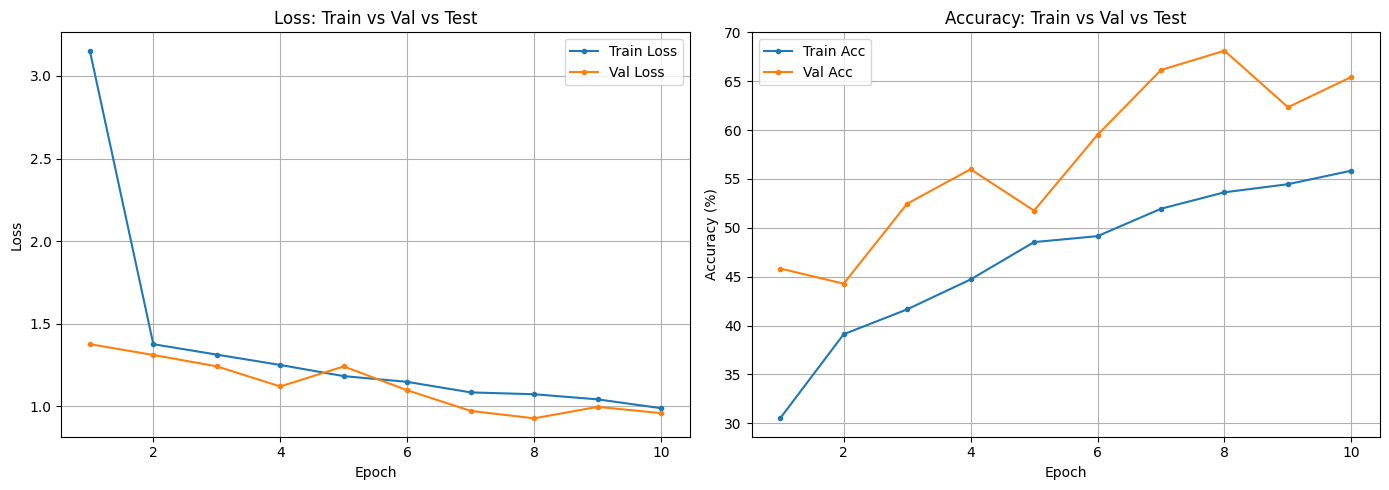

In [ ]:
"""
Dibuja las curvas de loss y accuracy para Train, Validation y Test.
Espera claves: 'train_loss', 'val_loss', 'test_loss' y sus equivalentes '_acc'.
"""
import matplotlib.pyplot as plt


epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# --- Gráfico 1: Loss (Pérdida) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history['val_loss'],   label='Val Loss',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: Train vs Val vs Test')
plt.legend()
plt.grid(True)

# --- Gráfico 2: Accuracy (Precisión) ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history['val_acc'],   label='Val Acc',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy: Train vs Val vs Test')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##Interpretación de la gráfica

Tenemos dos gráficas una con la pérdida y otra con la precisión de los dos conjuntos

En la gráfica de pérdida se puede observar una disminución constante de la perdida del entrenamiento.Pero en el caso de validacion se mantiene relativamente alto incluso empeorando y como se dijo anteriormente se ve un caso de overfiting

La gráfica de precisión, complementa esta interpretación.La train accuracy aumenta de forma constante hasta superar el 90 %, lo que confirma que el modelo aprende de los ejemplos de entrenamiento. No obstante, en la validacion las primeras épocas mejora hasta situarse alrededor del 73–75 %, pero después se estabiliza y no continúa aumentando pese a que la precisión del entrenamiento sigue creciendo.

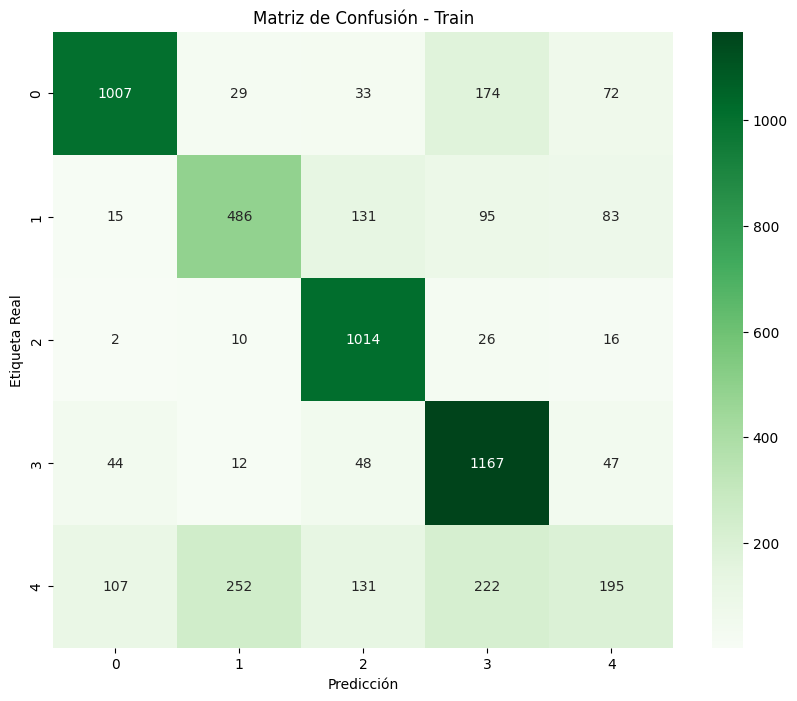

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Creamos una matriz de confusion para saber cuantos aciertos ha tenido una clase, y los fallos que ha tenido con cuales otras clases las ha confundido
#Con una dimension N x N, donde N es el numero de clases que tiene nuestro dataset

#Cambiamos al modo evaulacion para que las predicciones sean consistentes
net.eval()
#Listas para guardar predicciones y etiquetas
all_preds_train = []
all_labels_train = []

#Desactiva el calculo de gradientes asi ahorra memoria
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        #Convierte predicciones de tensor a lista numpy y las agrega a la lista de predicciones, y abajo lo msimo pero con las etiquetas.
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

conf_matrix_train = confusion_matrix(all_labels_train, all_preds_train)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Train')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

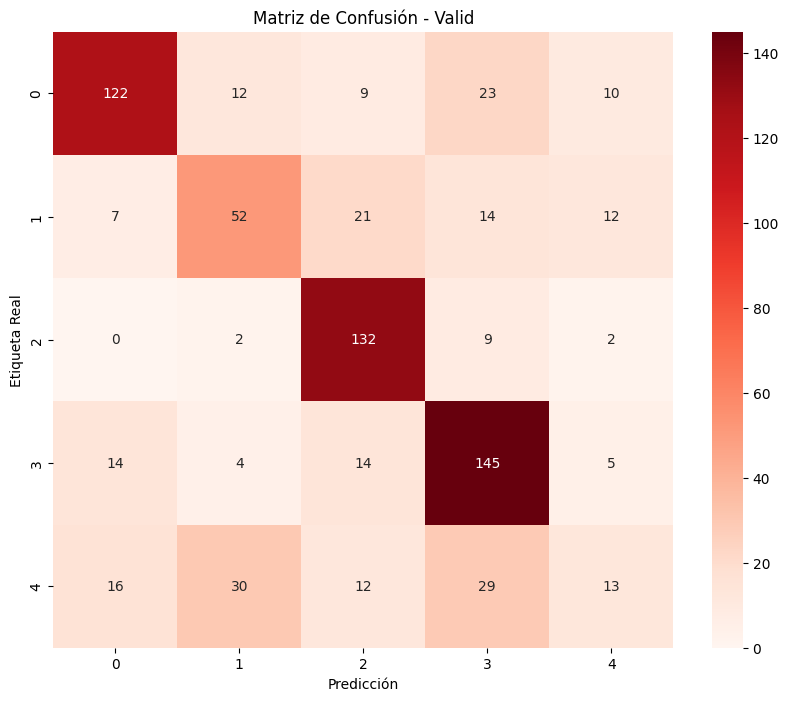

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Creamos una matriz de confusion para saber cuantos aciertos ha tenido una clase, y los fallos que ha tenido con cuales otras clases las ha confundido
#Con una dimension N x N, donde N es el numero de clases que tiene nuestro dataset

#Cambiamos al modo evaulacion para que las predicciones sean consistentes
net.eval()
#Listas para guardar predicciones y etiquetas
all_preds_valid = []
all_labels_valid = []

#Desactiva el calculo de gradientes asi ahorra memoria
with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        #Convierte predicciones de tensor a lista numpy y las agrega a la lista de predicciones, y abajo lo msimo pero con las etiquetas.
        all_preds_valid.extend(predicted.cpu().numpy())
        all_labels_valid.extend(labels.cpu().numpy())

conf_matrix_valid = confusion_matrix(all_labels_valid, all_preds_valid)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_valid, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión - Valid')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

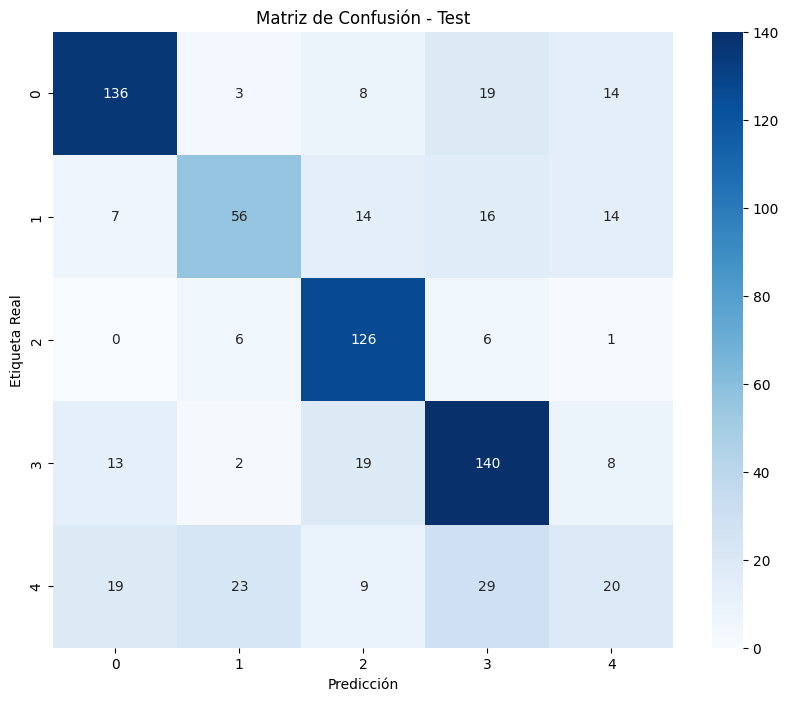

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Creamos una matriz de confusion para saber cuantos aciertos ha tenido una clase, y los fallos que ha tenido con cuales otras clases las ha confundido
#Con una dimension N x N, donde N es el numero de clases que tiene nuestro dataset

#Cambiamos al modo evaulacion para que las predicciones sean consistentes
net.eval()
#Listas para guardar predicciones y etiquetas
all_preds_test = []
all_labels_test = []

#Desactiva el calculo de gradientes asi ahorra memoria
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        #Convierte predicciones de tensor a lista numpy y las agrega a la lista de predicciones, y abajo lo msimo pero con las etiquetas.
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

##Resultado de la visualización de las matrices de confusión

Las matrices de confusión revelan que el modelo tiene más dificultades con la segunda y quinta clase. Esto era predecible debido al desbalanceo del dataset: estas clases contaban con menos imagenes que el resto, lo que dificulta que la red aprenda a classificarlas correctamentan